In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from copy import deepcopy
from astropy.cosmology import LambdaCDM
from astroML.correlation import bootstrap_two_point_angular
cc=3e5

import sys
sys.path.insert(0,'../g3code/')
from survey_volume import comoving_volume
from kdfof import kdFOF
from g3misc import *

def unc_median(x):
    nbs=1000
    unc = np.std(np.random.choice(x, size=(x,1000), replace=True), axis=1)
    assert x.size == unc.size
    return unc

def calcHaloID(simid):
    outID = deepcopy(np.asarray(simid))
    singles = (outID == -1)
    outID[singles]=np.arange(1,np.sum(singles)+1)+np.max(simid)
    unique_simIDs, unique_simidx = np.unique(outID, return_inverse=True)
    unique_haloIDs = np.arange(len(unique_simIDs))+1
    return unique_haloIDs[unique_simidx]

def getmhoffset(delta1, delta2, borc1, borc2, cc):
    """
    Credit: Ella Castelloe & Katie Eckert
    Adapted from Katie's code, using eqns from "Sample Variance Considerations for Cluster Surveys," Hu & Kravtsov (2003) ApJ, 584, 702
    (astro-ph/0203169)
    delta1 is overdensity of input, delta2 is overdensity of output -- for mock, delta1 = 200
    borc = 1 if wrt background density, borc = 0 if wrt critical density
    cc is concentration of halo- use cc=6
    """
    if borc1 == 0:
        delta1 = delta1/0.3
    if borc2 == 0:
        delta2 = delta2/0.3
    xin = 1./cc
    f_1overc = (xin)**3. * (np.log(1. + (1./xin)) - (1. + xin)**(-1.))
    f1 = delta1/delta2 * f_1overc
    a1=0.5116
    a2=-0.4283
    a3=-3.13e-3
    a4=-3.52e-5
    p = a2 + a3*np.log(f1) + a4*(np.log(f1))**2.
    x_f1 = (a1*f1**(2.*p) + (3./4.)**2.)**(-1./2.) + 2.*f1
    r2overr1 = x_f1
    m1overm2 = (delta1/delta2) * (1./r2overr1)**3. * (1./cc)**3.
    return m1overm2

In [2]:
eco_mocks=[]
zmax = 7000/3e5
zmin = 3000/3e5
ratio_200_337 = getmhoffset(200,337,1,1,6)
print(ratio_200_337)

for ii in range(8):
    mk = pd.read_csv(f'/Users/zhutchens/Documents/Research/ECO-halobiasmocks/ECO_cat_{ii}_Planck_memb_cat.csv')
    mk = mk[mk.M_r <= -17.33]
    mk.loc[:,'z'] = mk.loc[:,'cz'] / 3e5
    mk.loc[:,'loghalom'] = np.log10(ratio_200_337 * 10**mk.loc[:,'loghalom'])
    zmax = 7000 / 3e5 
    zmin = 3000 / 3e5 
    mk = mk[(mk.cz > cc*zmin) & (mk.cz < cc*zmax)]
    eco_mocks.append(mk)

1.1562439121818344


In [3]:
shark = pd.read_parquet('../catalogs/fibre_incomplete_mocks.parquet')
in_footprint1 = (shark.loc[:,'ra'] < 60)
in_footprint2 = (shark.loc[:,'ra'] > 60) & (shark.loc[:,'ra'] < 300)
in_footprint3 = (shark.loc[:,'ra'] > 300)
footprint = 1*in_footprint1 + 2*in_footprint2 + 3*in_footprint3
shark.loc[:,'footprint'] = footprint

simulation_id = deepcopy(shark.loc[:,'id_group_sky'].to_numpy())
haloid = calcHaloID(simulation_id)
shark.loc[:,'haloid']=haloid

# Uncomment line below if you want SHARK to match ECO mock in redshift range
#m2 = shark[(shark.mag_abs_r_SDSS<=-17.33) & (shark.redshift_observed>zmin) & (shark.redshift_observed<zmax)]

# Use line below if you want a larger SHARK volume to accomodate for smaller footprint
# 0.037 matches the ECO vol.
m2 = shark[(shark.mag_abs_r_SDSS<=-17.33) & (shark.redshift_observed>zmin) & (shark.redshift_observed<0.08)]

In [4]:
eco = pd.read_csv("../catalogs/h23_ecodr3_tab457.csv")
eco = eco[(eco.absrmag<=-17.33) & (eco.g3grpcz>3000) & (eco.g3grpcz<7000)]
eco.loc[:,'g3logmhvir'] = np.log10(ratio_200_337 * 10**eco.loc[:,'g3logmhvir'])

# $M_r$-$z$ Distribution

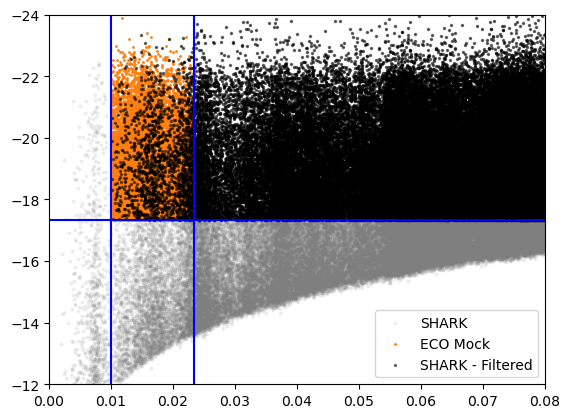

In [5]:
plt.figure()
plt.scatter(shark.redshift_observed, shark.mag_abs_r_SDSS, s=3, color='tab:gray', alpha=0.1, label='SHARK')
for em in eco_mocks[:1]:
    plt.scatter(em.z, em.M_r, s=1,color='tab:orange', label='ECO Mock')
plt.scatter(m2.redshift_observed, m2.mag_abs_r_SDSS, s=2, color='k', alpha=0.5, label='SHARK - Filtered')
plt.axhline(-17.33,color='blue')
plt.axvline(zmax,color='blue')
plt.axvline(zmin,color='blue')
plt.ylim(-12,-24)
plt.xlim(0,0.08)
plt.legend(loc='lower right')
plt.show()

# Footprint & Volume

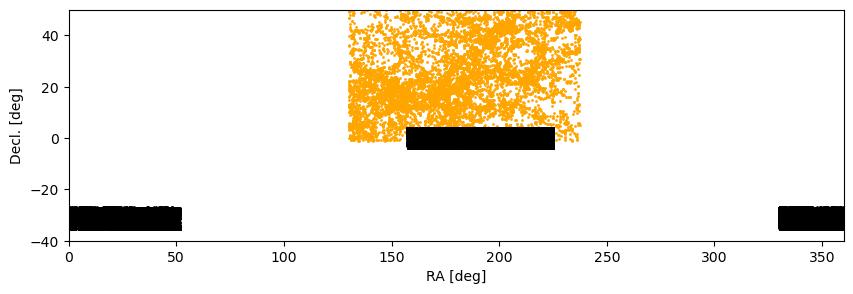

In [6]:
plt.figure(figsize=(10,3))
plt.scatter(eco_mocks[0].ra, eco_mocks[0].dec, color='orange', s=1)
plt.scatter(m2.ra, m2.dec, color='k', s=1)
plt.xlim(0,360)
plt.ylim(-40,50)
plt.xlabel("RA [deg]")
plt.ylabel("Decl. [deg]")
plt.show()

In [7]:
fp1 = m2[m2.footprint==1]
fp2 = m2[m2.footprint==2]
fp3 = m2[m2.footprint==3]
v1 = comoving_volume(fp1.ra.min(), fp1.ra.max(), fp1.dec.min(), fp1.dec.max(),\
                     fp1.redshift_observed.min(), fp1.redshift_observed.max(), 70, 0.3, 0.7)
v2 = comoving_volume(fp2.ra.min(), fp2.ra.max(), fp2.dec.min(), fp2.dec.max(),\
                     fp2.redshift_observed.min(), fp2.redshift_observed.max(), 70, 0.3, 0.7)
v3 = comoving_volume(fp3.ra.min(), fp3.ra.max(), fp3.dec.min(), fp3.dec.max(),\
                     fp3.redshift_observed.min(), fp3.redshift_observed.max(), 70, 0.3, 0.7)
m2vol = v1+v2+v3

em = eco_mocks[3]
ecovol = comoving_volume(em.ra.min(), em.ra.max(), em.dec.min(), em.dec.max(),\
                        em.z.min(), em.z.max(), 70, 0.3, 0.7)

print(f"ECO Mock Volume = {ecovol:0.5E} Mpc3")
print(f"SHARK Mock Volume = {m2vol:0.5E} Mpc3")
print(f"ECO/SHARK Vol Ratio = {ecovol/m2vol : 0.3f}")

ECO Mock Volume = 4.41238E+05 Mpc3
SHARK Mock Volume = 4.37074E+06 Mpc3
ECO/SHARK Vol Ratio =  0.101


# Number Density & Luminosity Function

In [8]:
m1ndens = len(em) / ecovol
m2ndens = len(m2) / m2vol
print(f"ECO Mock n = {m1ndens:0.5f} Mpc-3")
print(f"SHARK Mock n = {m2ndens:0.5f} Mpc-3")
print(f"ECO-SHARK n ratio = {m1ndens/m2ndens : 0.2f}")

ECO Mock n = 0.02721 Mpc-3
SHARK Mock n = 0.01593 Mpc-3
ECO-SHARK n ratio =  1.71


In [9]:
Lbin = np.arange(-23,-17.33,0.5)
Lbinc = 0.5 * (Lbin[1:] + Lbin[:-1])
dL = Lbin[1]-Lbin[0]
emLFs = []
emLFerrs=[]
for em in eco_mocks:
    emcounts = np.histogram(em.M_r, bins=Lbin)[0]
    emLFs.append(emcounts / ecovol) #/ dL
    emLFerrs.append(np.sqrt(emcounts) / ecovol)

m2Lcounts = np.histogram(m2.mag_abs_r_SDSS, bins=Lbin)[0]
m2LF = m2Lcounts / m2vol #/ dL
m2LFerr = np.sqrt(m2Lcounts) / m2vol

ecocounts = np.histogram(eco.absrmag, bins=Lbin)[0]
ecoLF = ecocounts / ecovol
ecoLFerr = np.sqrt(ecocounts) / ecovol

In [10]:
emLFs=np.array(emLFs)

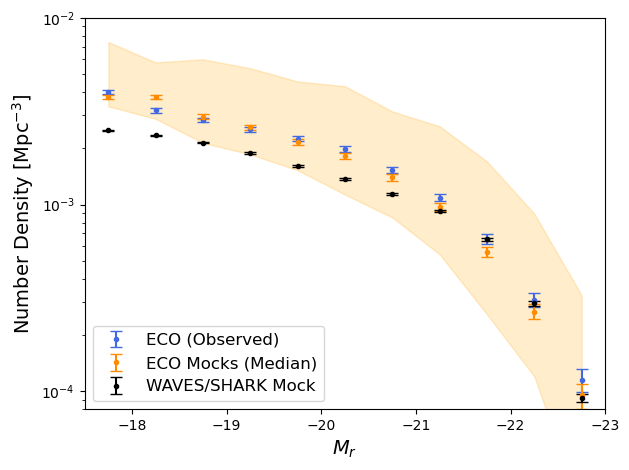

In [11]:
plt.figure()
#for i,lf in enumerate(emLFs): 
#    plt.plot(Lbinc, lf, '-', color='orange', alpha=0.2)
plt.fill_between(Lbinc, np.min(emLFs,axis=0), np.max(emLFs,axis=0), color='orange', alpha=0.2)
plt.errorbar(Lbinc, ecoLF, yerr=ecoLFerr, fmt='.', capsize=4, color='royalblue', label='ECO (Observed)')
plt.errorbar(Lbinc, np.median(emLFs,axis=0), yerr=np.median(emLFerrs,axis=0), fmt='.', capsize=4, color='darkorange', label="ECO Mocks (Median)")
plt.errorbar(Lbinc, m2LF, yerr=m2LFerr, fmt='.', color='k', capsize=4, label='WAVES/SHARK Mock')
plt.xlim(-17.5,-23.)
plt.ylim(8e-5,1e-2)
plt.yscale('log')
plt.xlabel("$M_r$",fontsize=14)
plt.ylabel("Number Density [Mpc$^{-3}$]",fontsize=14)
plt.legend(loc='lower left',fontsize=12)
plt.tight_layout()
plt.savefig("../figures/mock-LFcomparison.png",dpi=300)
plt.show()

In [12]:
print(ecoLF / m2LF)

[1.2473778  1.04189329 1.00900516 1.18140747 1.34734264 1.44940491
 1.39107732 1.33662817 1.31871173 1.36139846 1.60123415]


# Group Multiplicity Function

In [13]:
m2.loc[:,'halo_ngal'] = multiplicity_function(m2.loc[:,'haloid'].to_numpy(),True)
m2.loc[:,'loghalom'] = np.log10(m2.loc[:,'mass_virial_hosthalo'])

/var/folders/8m/dhcvf5t90qb04kx2vn0wbvl00000gp/T/ipykernel_8229/1620560015.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  m2.loc[:,'halo_ngal'] = multiplicity_function(m2.loc[:,'haloid'].to_numpy(),True)
/var/folders/8m/dhcvf5t90qb04kx2vn0wbvl00000gp/T/ipykernel_8229/1620560015.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  m2.loc[:,'loghalom'] = np.log10(m2.loc[:,'mass_virial_hosthalo'])


In [14]:
em_halos = []
for em in eco_mocks:
    em_halos.append(em.groupby('haloid').first())
m2_halos = m2.groupby('haloid').first()

In [15]:
nbins=np.arange(0.5,300.5,1)
nbinc = 0.5 * (nbins[1:] + nbins[:-1])
em_nN=[]
em_nN_err=[]
for ech in em_halos:
    emncounts = np.histogram(ech.halo_ngal, bins=nbins)[0]
    em_nN.append(emncounts / ecovol)
    em_nN_err.append(np.sqrt(emncounts)/ecovol)

m2ncounts = np.histogram(m2_halos.halo_ngal, bins=nbins)[0]
m2_nN =  m2ncounts / m2vol
m2_nN_err = np.sqrt(m2ncounts) / m2vol

In [16]:
em_nN=np.array(em_nN)
em_nN_err=np.array(em_nN_err)

In [17]:
eco_groups = eco.groupby('g3grp').first()
econcounts = np.histogram(eco_groups['g3grpngi']+eco_groups['g3grpndw'],bins=nbins)[0]
eco_nN = econcounts / ecovol
eco_nN_err = np.sqrt(econcounts) / ecovol

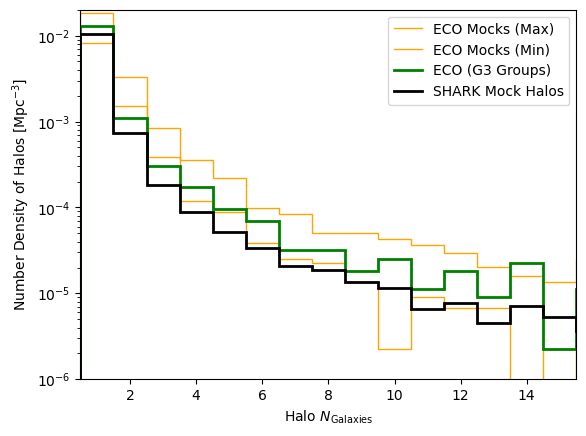

In [18]:
plt.figure()
#plt.stairs(np.median(eco_nN,axis=0), nbins, linewidth=3, color='orange', label='ECO Mocks')
plt.stairs(np.min(em_nN,axis=0), nbins, linewidth=1, color='orange', label='ECO Mocks (Max)')
plt.stairs(np.max(em_nN,axis=0), nbins, linewidth=1, color='orange', label='ECO Mocks (Min)')
plt.stairs(eco_nN, nbins, color='green', linewidth=2, label='ECO (G3 Groups)')
#plt.stairs(em_nN[2], nbins, linewidth=2, color='orange', label='ECO Mocks (Halos)')
plt.stairs(m2_nN, nbins, color='k', linewidth=2, label='SHARK Mock Halos')
plt.yscale('log')
plt.xlim(0.5,15.5)
plt.ylim(1e-6,2e-2)
plt.legend(loc='upper right')
plt.xlabel(r'Halo $N_{\rm Galaxies}$')
plt.ylabel("Number Density of Halos [Mpc$^{-3}$]")
plt.show()

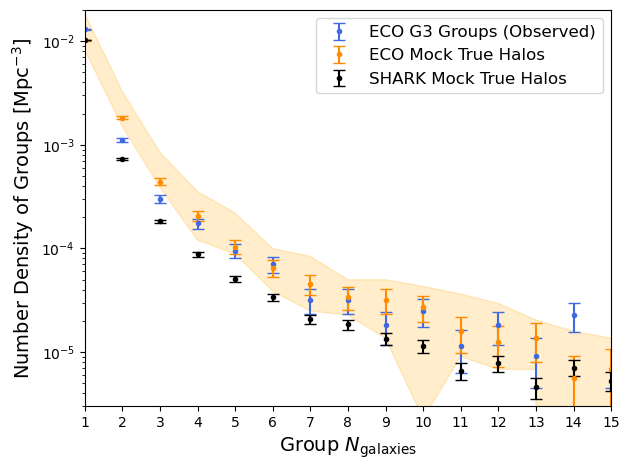

In [19]:
plt.figure()
nbinc = 0.5*(nbins[1:]+nbins[:-1])
#plt.stairs(np.median(eco_nN,axis=0), nbins, linewidth=3, color='orange', label='ECO Mocks')
plt.errorbar(nbinc, eco_nN, yerr=eco_nN_err, fmt='.', capsize=4, color='royalblue', label='ECO G3 Groups (Observed)')
plt.errorbar(nbinc, np.median(em_nN,axis=0), yerr=np.median(em_nN_err,axis=0), fmt='.', capsize=4, label='ECO Mock True Halos', color='darkorange')
plt.fill_between(nbinc, np.min(em_nN,axis=0), np.max(em_nN,axis=0), color='orange',alpha=0.2)
plt.errorbar(nbinc, m2_nN, yerr=m2_nN_err, fmt='.', capsize=4, color='k', label='SHARK Mock True Halos')
plt.yscale('log')
plt.xlim(0.5,15.5)
plt.ylim(3e-6,2e-2)
plt.legend(loc='upper right', fontsize=12)
plt.xticks(np.arange(1,16,1))
plt.xlim(1,15)
plt.xlabel(r'Group $N_{\rm galaxies}$',fontsize=14)
plt.ylabel("Number Density of Groups [Mpc$^{-3}$]",fontsize=14)
plt.tight_layout()
plt.savefig("../figures/mock-multf.png",dpi=300)
plt.show()

In [20]:
print(f"ECO-Mock Avg Density of Halos = {np.sum(em_nN[3]):0.4f} Mpc-3")
print(f"SHARK Avg Density of Halos = {np.sum(m2_nN):0.4f} Mpc-3")

ECO-Mock Avg Density of Halos = 0.0160 Mpc-3
SHARK Avg Density of Halos = 0.0116 Mpc-3


In [21]:
print(f"ECO-Mock Avg Density of N>=2 Halos = {np.sum(em_nN[3][nbinc>=2]):0.4f} Mpc-3")
print(f"SHARK Avg Density of N>=2 Halos = {np.sum(m2_nN[nbinc>=2]):0.4f} Mpc-3")

ECO-Mock Avg Density of N>=2 Halos = 0.0036 Mpc-3
SHARK Avg Density of N>=2 Halos = 0.0012 Mpc-3


In [22]:
print(f"Largest ECO-Mock Group N = {eco_mocks[3].halo_ngal.max()}")
print(f"Largest SHARK Group N = {m2.halo_ngal.max()}")

Largest ECO-Mock Group N = 206
Largest SHARK Group N = 271


# Halo Mass Function

In [23]:
em_logmh = []
for em in em_halos:
    em_logmh.append(em.loghalom.to_numpy())
m2_logmh = m2_halos.loghalom.to_numpy()

In [24]:
logMbins = np.arange(10,14.5,0.2)
logMbinc = 0.5 * (logMbins[:-1] + logMbins[1:])
dlogM = logMbins[1]-logMbins[0] 

In [25]:
em_dndlogM = []
for logmh_ in em_logmh:
    em_dndlogM.append(np.histogram(logmh_, bins=logMbins)[0] / ecovol / dlogM)
em_dndlogM = np.array(em_dndlogM)
m2_dndlogM = np.histogram(m2_logmh, bins=logMbins)[0] / m2vol / dlogM

em_nc = []
for dndlogM in em_dndlogM:
    em_nc.append(np.cumsum(dndlogM[::-1] * dlogM)[::-1])
em_nc = np.array(em_nc)
m2_nc = np.cumsum(m2_dndlogM[::-1] * dlogM)[::-1]

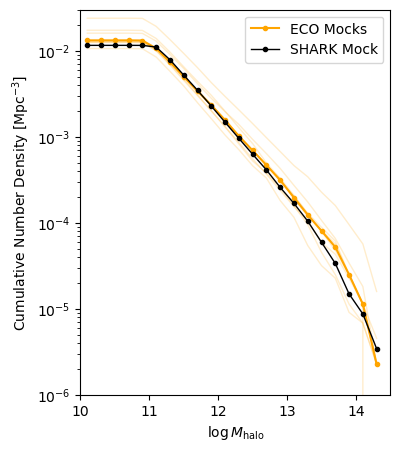

In [26]:
plt.figure(figsize=(4,5))
for nc in em_nc:
    plt.plot(logMbinc, nc, '-', alpha=0.2, color='orange', linewidth=1)
plt.plot(logMbinc, np.median(em_nc,axis=0), '.-', color='orange', label='ECO Mocks')
plt.plot(logMbinc, m2_nc, '.-',color='k', linewidth=1, label='SHARK Mock')
plt.ylim(1e-6,3e-2)
plt.yscale('log')
plt.xlim(10,14.5)
plt.xlabel(r"$\log M_{\rm halo}$")
plt.ylabel("Cumulative Number Density [Mpc$^{-3}$]")
plt.legend(loc='best')
plt.show()

# HOD

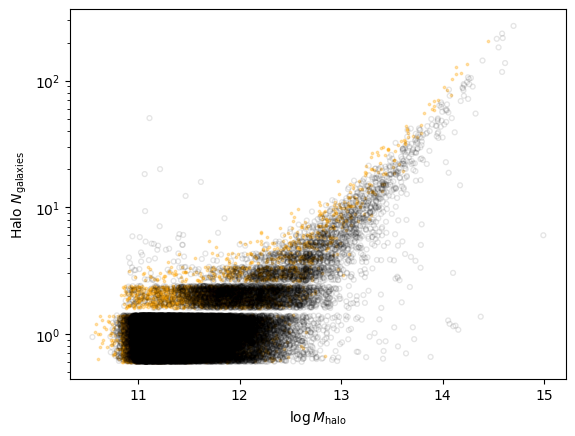

In [27]:
plt.figure()
jitter1 = np.random.uniform(-0.4,0.4,len(em_halos[3]))
jitter2 = np.random.uniform(-0.4,0.4,len(m2_halos))
plt.scatter(em_halos[3].loghalom, em_halos[3].halo_ngal+jitter1, color='orange', alpha=0.3,s=3)
plt.scatter(m2_halos.loghalom, m2_halos.halo_ngal+jitter2, facecolor='None', edgecolor='k', s=12, alpha=0.1)
plt.yscale('log')
plt.xlabel(r'$\log M_{\rm halo}$')
plt.ylabel(r'Halo $N_{\rm galaxies}$')
plt.show()

In [28]:
em_groups=[]
for em in eco_mocks:
    em_groups.append(em.groupby('g3grp_l').first())

In [29]:
em_Navg=[]
for ech in em_halos:
    em_Navg.append(binned_statistic(ech.loghalom, ech.halo_ngal, bins=logMbins)[0])
m2_Navg = binned_statistic(m2_halos.loghalom, m2_halos.halo_ngal, bins=logMbins)[0]
#eco_Navg = binned_statistic(em_groups[2].g3logmh_l, em_groups[2].g3grpn_l, bins=logMbins)[0]
eco_Navg = binned_statistic(eco_groups.g3logmhvir, eco_groups.g3grpngi+eco_groups.g3grpndw, bins=logMbins)[0]

/var/folders/8m/dhcvf5t90qb04kx2vn0wbvl00000gp/T/ipykernel_8229/1480923247.py:5: RuntimeWarning: All-NaN slice encountered
  plt.plot(logMbinc, np.nanmedian(em_Navg,axis=0), '.-', color='orange', label='ECO Mock')


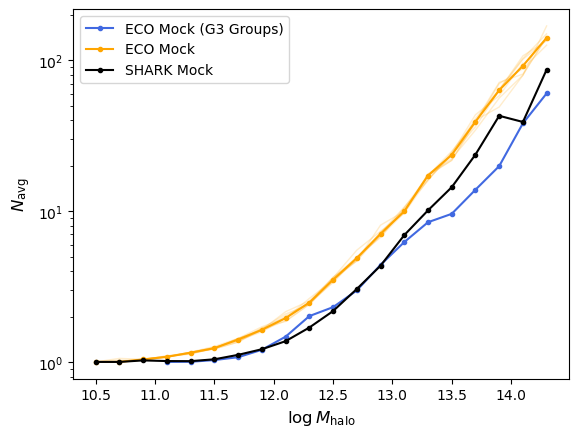

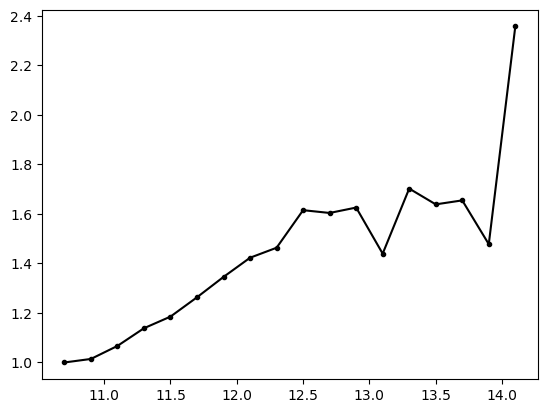

In [30]:
plt.figure()
plt.plot(logMbinc, eco_Navg, '.-', color='royalblue', label='ECO Mock (G3 Groups)')
for navg in em_Navg:
    plt.plot(logMbinc, navg, '-', alpha=0.2, color='orange', linewidth=1)
plt.plot(logMbinc, np.nanmedian(em_Navg,axis=0), '.-', color='orange', label='ECO Mock')
plt.plot(logMbinc, m2_Navg, '.-', color='k', label='SHARK Mock')
plt.yscale('log')
plt.xlabel(r'$\log M_{\rm halo}$', fontsize=12)
plt.ylabel(r'$N_{\rm avg}$', fontsize=12)
plt.legend(loc='best')
plt.show()

plt.figure()
plt.plot(logMbinc, np.median(em_Navg,axis=0) / m2_Navg, 'k.-')
plt.show()

# Clustering

In [ ]:
# assert m2.redshift_observed.max()<0.025, "ECO and SHARK must be matched in redshift range."
# plt.figure()
# cbins = 10 ** np.linspace(np.log10(1 / 60.), np.log10(6), 16)
# cbinc = 0.5*(cbins[1:]+cbins[:-1])
# nbs=100

# # ECO Mocks
# wtheta_ecomocks=[]
# for ecm in eco_mocks:
#     corr,dcorr,_ = bootstrap_two_point_angular(ecm.ra, ecm.dec, bins=cbins, method='standard', Nbootstraps=nbs)
#     wtheta_ecomocks.append(corr)
#     #plt.errorbar(cbinc, corr, yerr=dcorr, fmt='.', color='orange', lw=1, alpha=0.4, label='ECO Mocks')
# plt.fill_between(cbinc, np.min(wtheta_ecomocks,axis=0), np.max(wtheta_ecomocks,axis=0), color='orange', alpha=0.4)#, label='ECO Mocks (Median), shading=cosmic variance')
# plt.errorbar(cbinc, np.median(wtheta_ecomocks,axis=0), yerr=dcorr, fmt='.', capsize=4, color='darkorange', lw=1, label='ECO Mocks (Median)\nshading=cosmic variance')

# # ECO
# corr, dcorr, _ = bootstrap_two_point_angular(eco.radeg, eco.dedeg, bins=cbins, method='standard', Nbootstraps=nbs)
# plt.errorbar(cbinc, corr, yerr=dcorr, fmt='.', capsize=4, color='royalblue', lw=1, label='ECO (Observed)')

# # SHARK
# corr_fp1,dcorr1,_ = bootstrap_two_point_angular(m2[m2.footprint==1].ra,\
#     m2[m2.footprint==1].dec, bins=cbins, method='standard', Nbootstraps=nbs)
# corr_fp2,dcorr2,_ = bootstrap_two_point_angular(m2[m2.footprint==2].ra,\
#     m2[m2.footprint==2].dec, bins=cbins, method='standard', Nbootstraps=nbs)
# corr_fp3,dcorr3,_ = bootstrap_two_point_angular(m2[m2.footprint==3].ra,\
#     m2[m2.footprint==3].dec, bins=cbins, method='standard', Nbootstraps=nbs)
# shark_corr = np.median([corr_fp1,corr_fp2,corr_fp3],axis=0)
# shark_dcorr = np.median([dcorr1,dcorr2,dcorr3],axis=0)
# plt.errorbar(cbinc, shark_corr, yerr=shark_dcorr, fmt='.', capsize=4, color='k', label='SHARK')
# # plt.errorbar(cbinc, corr_fp1, yerr=dcorr1, fmt='.-', color='k', lw=1, label='SHARK/WAVES-Wide')
# # plt.errorbar(cbinc, corr_fp2, yerr=dcorr2, fmt='.-', markerfacecolor='None', markeredgecolor='k', lw=1, label='SHARK/WAVES-Wide')
# # plt.errorbar(cbinc, corr_fp3, yerr=dcorr3, fmt='.-', color='gray', lw=1, label='SHARK/WAVES-Deep', markersize=10)


# plt.gca().set_yscale('log')
# plt.gca().set_xscale('log')
# plt.gca().set_xlim(1e-2,8)
# plt.gca().set_ylim(1e-1,100)
# plt.gca().set_xlabel(r'$\theta$ [deg]',fontsize=14)
# plt.gca().set_ylabel(r'$\omega(\theta)$',fontsize=14)
# plt.legend(loc='best',fontsize=12)
# plt.tight_layout()
# plt.savefig("../figures/mocks-2pt.png",dpi=300)
# plt.show()

In [ ]:
# corr / shark_corr

In [ ]:
# corr / np.median(wtheta_ecomocks,axis=0)

# $R_{\rm proj,gal}$ and $\Delta v_{\rm proj,gal}$ Distributions

In [ ]:
m1 = eco_mocks[4] # same result below for all ECO mocks

In [ ]:
cosmo = LambdaCDM(70,0.3,0.7)

In [ ]:
m1halora, m1halodec, m1haloz = group_skycoords(m1.ra, m1.dec, m1.z, m1.haloid)
m1_alpha_ij = angular_separation(m1.ra, m1.dec, m1halora, m1halodec)
m1_rprojgal = m1_alpha_ij * cosmo.comoving_transverse_distance(m1haloz)
m1_Dvprojgal = cc * np.abs(m1.z - m1haloz) / (1 + m1haloz)

In [ ]:
m2halora, m2halodec, m2haloz = group_skycoords(m2.ra, m2.dec, m2.redshift_observed, m2.haloid)
m2_alpha_ij = angular_separation(m2.ra, m2.dec, m2halora, m2halodec)
m2_rprojgal = m2_alpha_ij * cosmo.comoving_transverse_distance(m2haloz)
m2_Dvprojgal = cc * np.abs(m2.redshift_observed - m2haloz) / (1 + m2haloz)

In [ ]:
g3_alpha_ij = angular_separation(eco.radeg, eco.dedeg, eco.g3grpradeg, eco.g3grpdedeg)
g3_rprojgal = g3_alpha_ij * cosmo.comoving_transverse_distance(eco.g3grpcz/3e5)
g3_Dvprojgal = np.abs(eco.cz - eco.g3grpcz) / (1 + eco.g3grpcz/3e5)

In [ ]:
pt16 = lambda x: np.percentile(x,16)
pt84 = lambda x: np.percentile(x,84)

In [ ]:
logMbins = np.arange(11,14.5,0.25)
logMbinc = 0.5 * (logMbins[1:] + logMbins[:-1])

In [ ]:
m1_median_rprojgal = binned_statistic(m1.loghalom, m1_rprojgal, bins=logMbins, statistic='median')[0]
m1_pt16_rprojgal = binned_statistic(m1.loghalom, m1_rprojgal, bins=logMbins, statistic=pt16)[0]
m1_pt84_rprojgal = binned_statistic(m1.loghalom, m1_rprojgal, bins=logMbins, statistic=pt84)[0]

m1_median_Dvprojgal = binned_statistic(m1.loghalom, m1_Dvprojgal, bins=logMbins, statistic='median')[0]
m1_pt16_Dvprojgal = binned_statistic(m1.loghalom, m1_Dvprojgal, bins=logMbins, statistic=pt16)[0]
m1_pt84_Dvprojgal = binned_statistic(m1.loghalom, m1_Dvprojgal, bins=logMbins, statistic=pt84)[0]

In [ ]:
m2_median_rprojgal = binned_statistic(m2.loghalom, m2_rprojgal, bins=logMbins, statistic='median')[0]
m2_pt16_rprojgal = binned_statistic(m2.loghalom, m2_rprojgal, bins=logMbins, statistic=pt16)[0]
m2_pt84_rprojgal = binned_statistic(m2.loghalom, m2_rprojgal, bins=logMbins, statistic=pt84)[0]

m2_median_Dvprojgal = binned_statistic(m2.loghalom, m2_Dvprojgal, bins=logMbins, statistic='median')[0]
m2_pt16_Dvprojgal = binned_statistic(m2.loghalom, m2_Dvprojgal, bins=logMbins, statistic=pt16)[0]
m2_pt84_Dvprojgal = binned_statistic(m2.loghalom, m2_Dvprojgal, bins=logMbins, statistic=pt84)[0]

In [ ]:
g3_median_rprojgal = binned_statistic(eco.g3logmhvir, g3_rprojgal, bins=logMbins, statistic='median')[0]
g3_pt16_rprojgal = binned_statistic(eco.g3logmhvir, g3_rprojgal, bins=logMbins, statistic=pt16)[0]
g3_pt84_rprojgal = binned_statistic(eco.g3logmhvir, g3_rprojgal, bins=logMbins, statistic=pt84)[0]

g3_median_Dvprojgal = binned_statistic(eco.g3logmhvir, g3_Dvprojgal, bins=logMbins, statistic='median')[0]
g3_pt16_Dvprojgal = binned_statistic(eco.g3logmhvir, g3_Dvprojgal, bins=logMbins, statistic=pt16)[0]
g3_pt84_Dvprojgal = binned_statistic(eco.g3logmhvir, g3_Dvprojgal, bins=logMbins, statistic=pt84)[0]

In [ ]:
fig, axs = plt.subplots(ncols=2,figsize=(10,4))

axs[0].plot(logMbinc, m1_median_rprojgal, color='orange', linewidth=2, label=r'ECO Mock (median $\pm$ 34%)')
axs[0].fill_between(logMbinc, m1_pt16_rprojgal, m1_pt84_rprojgal, color='orange', alpha=0.5)
axs[0].plot(logMbinc, m2_median_rprojgal, color='k', linewidth=2, label=r'SHARK (median $\pm$ 34%)')
axs[0].fill_between(logMbinc, m2_pt16_rprojgal, m2_pt84_rprojgal, color='gray', alpha=0.2)

axs[1].plot(logMbinc, m1_median_Dvprojgal, color='orange', linewidth=2, label=r'ECO Mock (median $\pm$ 34%)')
axs[1].fill_between(logMbinc, m1_pt16_Dvprojgal, m1_pt84_Dvprojgal, color='orange', alpha=0.5)
axs[1].plot(logMbinc, m2_median_Dvprojgal, color='k', linewidth=2, label=r'SHARK (median $\pm$ 34%)')
axs[1].fill_between(logMbinc, m2_pt16_Dvprojgal, m2_pt84_Dvprojgal, color='gray', alpha=0.2)

axs[0].legend(loc='upper left')
axs[0].set_ylabel(r'$R_{\rm proj,gal}$ [Mpc]',fontsize=14)
axs[1].set_ylabel(r'$\Delta v_{\rm proj,gal}$ [km s$^{-1}$]',fontsize=14)
axs[0].set_ylim(0,0.8)
axs[1].set_ylim(0,800)
for ax in axs:
    ax.set_xlabel(r'$\log M_{\rm halo}$',fontsize=14)
    ax.set_xlim(11,14.1)
plt.tight_layout()
plt.show()

In [ ]:
fig, axs = plt.subplots(ncols=2,figsize=(10,4))

axs[0].plot(logMbinc, m1_median_rprojgal, color='darkorange', linewidth=2, label=r'Single ECO Mock (median $\pm$ 34%)')
axs[0].fill_between(logMbinc, m1_pt16_rprojgal, m1_pt84_rprojgal, color='orange', alpha=0.3)
axs[0].plot(logMbinc, g3_median_rprojgal, color='royalblue', linewidth=2, label=r'ECO/G3 (median $\pm$ 34%)')
axs[0].plot(logMbinc, g3_pt16_rprojgal, linestyle='dashed', color='royalblue')
axs[0].plot(logMbinc, g3_pt84_rprojgal, linestyle='dashed', color='royalblue')
axs[0].plot(logMbinc, m2_median_rprojgal, color='k', linewidth=2, label=r'SHARK (median $\pm$ 34%)')
axs[0].plot(logMbinc, m2_pt16_rprojgal, linestyle='dashed', color='k')
axs[0].plot(logMbinc, m2_pt84_rprojgal, linestyle='dashed', color='k')

axs[1].plot(logMbinc, m1_median_Dvprojgal, color='darkorange', linewidth=2, label=r'Single ECO Mock (median $\pm$ 34%)')
axs[1].fill_between(logMbinc, m1_pt16_Dvprojgal, m1_pt84_Dvprojgal, color='orange', alpha=0.3)
axs[1].plot(logMbinc, g3_median_Dvprojgal, color='royalblue', linewidth=2, label=r'ECO/G3 (median $\pm$ 34%)')
axs[1].plot(logMbinc, g3_pt16_Dvprojgal, linestyle='dashed', color='royalblue')
axs[1].plot(logMbinc, g3_pt84_Dvprojgal, linestyle='dashed', color='royalblue')
axs[1].plot(logMbinc, m2_median_Dvprojgal, color='k', linewidth=2, label=r'SHARK (median $\pm$ 34%)')
axs[1].plot(logMbinc, m2_pt16_Dvprojgal, linestyle='dashed', color='k')
axs[1].plot(logMbinc, m2_pt84_Dvprojgal, linestyle='dashed', color='k')

axs[0].legend(loc='upper left')
axs[0].set_ylabel(r'$R_{\rm proj,gal}$ [Mpc]',fontsize=14)
axs[1].set_ylabel(r'$\Delta v_{\rm proj,gal}$ [km s$^{-1}$]',fontsize=14)
axs[0].set_ylim(0,0.8)
axs[1].set_ylim(0,800)
for ax in axs:
    ax.set_xlabel(r'$\log M_{\rm halo}$',fontsize=14)
    ax.set_xlim(11,14.1)
plt.tight_layout()
plt.savefig("../figures/mock_groupcentric-rp-vp-dists.png",dpi=300)
plt.show()

In [ ]:
print(m2_median_rprojgal / m1_median_rprojgal)

In [ ]:
fig, axs=plt.subplots(ncols=2)
axs[0].plot(logMbinc, m2_median_rprojgal - m1_median_rprojgal)
axs[1].plot(logMbinc, m2_median_Dvprojgal - m1_median_Dvprojgal)

# $R_{\rm proj,gal}$ and $\Delta v_{\rm proj,gal}$ Distributions for FOF Groups (matching H23)

In [ ]:
bperp=0.07
blos=1.1
smean = (ecovol / len(eco)) ** (1/3.)
cosmo = LambdaCDM(70,0.3,0.7)

In [ ]:
print((m2vol / len(m2))**(1/3.))

In [ ]:
m2.loc[:,'fofid'] = kdFOF(m2.ra, m2.dec, m2.redshift_observed, bperp, blos, (m2vol / len(m2))**(1/3.), cosmo)
eco.loc[:,'fofid'] = kdFOF(eco.radeg, eco.dedeg, eco.cz/3e5, bperp, blos, smean, cosmo)
for em in eco_mocks:
    em.loc[:,'fofid'] = kdFOF(em.ra, em.dec, em.cz/3e5, bperp, blos, smean, cosmo)

In [ ]:
grpra,grpdec,grpz = group_skycoords(eco.radeg,eco.dedeg,eco.cz/3e5,eco.fofid)
grpn = multiplicity_function(eco.fofid,True)
eco.loc[:,'fofradeg'] = grpra
eco.loc[:,'fofdedeg'] = grpdec
eco.loc[:,'fofz'] = grpz
eco.loc[:,'fofn'] = grpn
eco.loc[:,'alpha_ij'] = angular_separation(eco.radeg, eco.dedeg, eco.fofradeg, eco.fofdedeg)
eco.loc[:,'rprojgal'] = eco.loc[:,'alpha_ij'] * cosmo.comoving_transverse_distance(eco.fofz).to('Mpc').value
eco.loc[:,'vprojgal'] = np.abs(eco.loc[:,'cz'] - cc*eco.loc[:,'fofz']) / (1+eco.loc[:,'fofz'])

grpra,grpdec,grpz = group_skycoords(m2.ra,m2.dec,m2.redshift_observed,m2.fofid)
grpn = multiplicity_function(m2.fofid,True)
m2.loc[:,'fofradeg'] = grpra
m2.loc[:,'fofdedeg'] = grpdec
m2.loc[:,'fofz'] = grpz
m2.loc[:,'fofn'] = grpn
m2.loc[:,'alpha_ij'] = angular_separation(m2.ra, m2.dec, m2.fofradeg, m2.fofdedeg)
m2.loc[:,'rprojgal'] = m2.loc[:,'alpha_ij'] * cosmo.comoving_transverse_distance(m2.fofz).to('Mpc').value                     
m2.loc[:,'vprojgal'] = cc*np.abs(m2.loc[:,'redshift_observed'] - m2.loc[:,'fofz']) / (1+m2.loc[:,'fofz'])

for em in eco_mocks:
    grpra,grpdec,grpz = group_skycoords(em.ra,em.dec,em.cz/3e5,em.fofid)
    grpn = multiplicity_function(em.fofid,True)
    em.loc[:,'fofradeg'] = grpra
    em.loc[:,'fofdedeg'] = grpdec
    em.loc[:,'fofz'] = grpz
    em.loc[:,'fofn'] = grpn
    em.loc[:,'alpha_ij'] = angular_separation(em.ra, em.dec, em.fofradeg, em.fofdedeg)
    em.loc[:,'rprojgal'] = em.loc[:,'alpha_ij'] * cosmo.comoving_transverse_distance(em.fofz).to('Mpc').value                    
    em.loc[:,'vprojgal'] = np.abs(em.loc[:,'cz'] - cc*em.loc[:,'fofz']) / (1+em.loc[:,'fofz'])

In [ ]:
grpNbin=np.logspace(0.01,2,20)#np.arange(1.5,100.5,1)
grpNbinc = 0.5*(grpNbin[1:]+grpNbin[:-1])

In [ ]:
#np.logspace(0,2,20)

In [ ]:
m2_median_rprojgal = binned_statistic(m2.fofn, m2.rprojgal, bins=grpNbin, statistic='median')[0]
m2_pt16_rprojgal = binned_statistic(m2.fofn, m2.rprojgal, bins=grpNbin, statistic=pt16)[0]
m2_pt84_rprojgal = binned_statistic(m2.fofn, m2.rprojgal, bins=grpNbin, statistic=pt84)[0]

m2_median_Dvprojgal = binned_statistic(m2.fofn, m2.vprojgal, bins=grpNbin, statistic='median')[0]
m2_pt16_Dvprojgal = binned_statistic(m2.fofn, m2.vprojgal, bins=grpNbin, statistic=pt16)[0]
m2_pt84_Dvprojgal = binned_statistic(m2.fofn, m2.vprojgal, bins=grpNbin, statistic=pt84)[0]

In [ ]:
eco_median_rprojgal = binned_statistic(eco.fofn, eco.rprojgal, bins=grpNbin, statistic='median')[0]
eco_pt16_rprojgal = binned_statistic(eco.fofn, eco.rprojgal, bins=grpNbin, statistic=pt16)[0]
eco_pt84_rprojgal = binned_statistic(eco.fofn, eco.rprojgal, bins=grpNbin, statistic=pt84)[0]

eco_median_Dvprojgal = binned_statistic(eco.fofn, eco.vprojgal, bins=grpNbin, statistic='median')[0]
eco_pt16_Dvprojgal = binned_statistic(eco.fofn, eco.vprojgal, bins=grpNbin, statistic=pt16)[0]
eco_pt84_Dvprojgal = binned_statistic(eco.fofn, eco.vprojgal, bins=grpNbin, statistic=pt84)[0]

In [ ]:
choice=0
em_median_rprojgal = binned_statistic(eco_mocks[choice].fofn, eco_mocks[choice].rprojgal, bins=grpNbin, statistic='median')[0]
em_pt16_rprojgal = binned_statistic(eco_mocks[choice].fofn, eco_mocks[choice].rprojgal, bins=grpNbin, statistic=pt16)[0]
em_pt84_rprojgal = binned_statistic(eco_mocks[choice].fofn, eco_mocks[choice].rprojgal, bins=grpNbin, statistic=pt84)[0]

em_median_Dvprojgal = binned_statistic(eco_mocks[choice].fofn, eco_mocks[choice].vprojgal, bins=grpNbin, statistic='median')[0]
em_pt16_Dvprojgal = binned_statistic(eco_mocks[choice].fofn, eco_mocks[choice].vprojgal, bins=grpNbin, statistic=pt16)[0]
em_pt84_Dvprojgal = binned_statistic(eco_mocks[choice].fofn, eco_mocks[choice].vprojgal, bins=grpNbin, statistic=pt84)[0]

In [ ]:
fig, axs = plt.subplots(ncols=2, figsize=(11,4))
axs[0].errorbar(grpNbinc, eco_median_rprojgal, yerr=[eco_pt16_rprojgal, eco_pt84_rprojgal], color='royalblue', fmt='.', capsize=3, label='ECO FoF Groups (Observed)')
axs[0].errorbar(grpNbinc, em_median_rprojgal, yerr=[em_pt16_rprojgal, em_pt84_rprojgal], color='darkorange', fmt='.', capsize=3, label='ECO Mock FoF Groups')
axs[0].errorbar(grpNbinc, m2_median_rprojgal, yerr=[m2_pt16_rprojgal, m2_pt84_rprojgal], color='k', fmt='.', capsize=3, label='SHARK FoF Groups')
axs[1].errorbar(grpNbinc, eco_median_Dvprojgal, yerr=[eco_pt16_Dvprojgal, eco_pt84_Dvprojgal], color='royalblue', fmt='.', capsize=3, label='ECO FoF Groups (Observed)')
axs[1].errorbar(grpNbinc, em_median_Dvprojgal, yerr=[em_pt16_Dvprojgal, em_pt84_Dvprojgal], color='darkorange', fmt='.', capsize=3, label='ECO Mock FoF Groups')
axs[1].errorbar(grpNbinc, m2_median_Dvprojgal, yerr=[m2_pt16_Dvprojgal, m2_pt84_Dvprojgal], color='k', fmt='.', capsize=3, label='SHARK FOF Groups')
for ax in axs: 
    ax.set_xlabel(r"FoF Group $N_{\rm galaxies}$")
    ax.set_xlim(0,80.5)
axs[0].set_ylim(0,1.2)
axs[0].set_ylabel(r"$R_{\rm proj,gal}$ Distribution")
axs[1].set_ylabel(r"$\Delta v_{\rm proj,gal}$ Distribution")
axs[1].legend(loc='upper left',framealpha=0)
plt.show()

In [ ]:
np.nanmedian(m2_median_rprojgal / eco_median_rprojgal)

In [ ]:
fig, axs = plt.subplots(ncols=2, figsize=(11,4))
axs[0].errorbar(np.log10(grpNbinc), eco_median_rprojgal, yerr=[eco_pt16_rprojgal, eco_pt84_rprojgal], color='royalblue', fmt='.', capsize=3, label='ECO FoF Groups (Observed)')
axs[0].errorbar(np.log10(grpNbinc), em_median_rprojgal, yerr=[em_pt16_rprojgal, em_pt84_rprojgal], color='darkorange', fmt='.', capsize=3, label='ECO Mock FoF Groups')
axs[0].errorbar(np.log10(grpNbinc), m2_median_rprojgal, yerr=[m2_pt16_rprojgal, m2_pt84_rprojgal], color='k', fmt='.', capsize=3, label='SHARK FoF Groups')
axs[1].errorbar(np.log10(grpNbinc), eco_median_Dvprojgal, yerr=[eco_pt16_Dvprojgal, eco_pt84_Dvprojgal], color='royalblue', fmt='.', capsize=3, label='ECO FoF Groups (Observed)')
axs[1].errorbar(np.log10(grpNbinc), em_median_Dvprojgal, yerr=[em_pt16_Dvprojgal, em_pt84_Dvprojgal], color='darkorange', fmt='.', capsize=3, label='ECO Mock FoF Groups')
axs[1].errorbar(np.log10(grpNbinc), m2_median_Dvprojgal, yerr=[m2_pt16_Dvprojgal, m2_pt84_Dvprojgal], color='k', fmt='.', capsize=3, label='SHARK FOF Groups')
for ax in axs: ax.set_xlabel(r"$\log_{10}$ FoF Group $N_{\rm galaxies}$")
axs[0].set_ylabel(r"$R_{\rm proj,gal}$ Distribution")
axs[0].set_ylabel(r"$\Delta v_{\rm proj,gal}$ Distribution")
axs[0].legend(loc='upper left')
plt.show()

In [ ]:
grpNbin

# $z_{\rm obs} - z_{\rm cos}$ Velocity Bias

In [ ]:
fig, axs = plt.subplots(ncols=2, figsize=(11,4))

axs[0].scatter(m1.cz_nodist/cc, m1.cz/cc - m1.cz_nodist/cc, s=1, alpha=0.5)
axs[1].scatter(m2.redshift_cosmological, m2.redshift_observed-m2.redshift_cosmological, s=1, alpha=0.1)
print(np.median(m1.cz/cc - m1.cz_nodist/cc))
print(np.median(m2.redshift_observed-m2.redshift_cosmological))
plt.show()

In [ ]:
plt.figure()
plt.grid()
dz=m2.redshift_observed-m2.redshift_cosmological
median, bins, _ = binned_statistic(m2.redshift_cosmological, dz, bins=15, statistic='median')
plt.scatter(m2.redshift_cosmological, dz, s=1, alpha=0.1, label='median')
plt.plot(0.5*(bins[1:]+bins[:-1]), median, 'k.-')
plt.ylim(-0.005,0.005)
plt.ylabel(r'$z_{\rm obs}-z_{\rm cos}$',fontsize=14)
plt.xlabel(r'$z_{\rm cos}$',fontsize=14)
plt.legend(loc='best')
plt.tight_layout()
plt.savefig("../figures/dz_m2.png")
plt.show()

In [ ]:
fig, axs = plt.subplots(ncols=2, figsize=(11,4))

axs[0].scatter(m1.loghalom, m1.cz/cc - m1.cz_nodist/cc, s=1, alpha=0.5)
axs[1].scatter(m2.loghalom, m2.redshift_observed-m2.redshift_cosmological, s=1, alpha=0.1)
print(np.median(m1.cz/cc - m1.cz_nodist/cc))
print(np.median(m2.redshift_observed-m2.redshift_cosmological))
plt.show()